# Sensor de sudor multimodal: 4 biomarcadores en 21 días

**4 biomarcadores en tu sudor. 21 días. Sin tocarlo.**

Un sensor inalámbrico, del tamaño de una curita, que mide cortisol, urea, lactato y glucosa al mismo tiempo. Y cuando se "satura", se autolimpia con un pulso de voltaje. Así, sin tu intervención.

Veamos cuánto aguanta y qué tan bien detecta el estrés.

📄 **Paper**: [Wireless and in situ regenerable multimodal wearable bioelectronic sweat sensor](https://doi.org/10.1038/s41551-026-01670-2)
*Nature Biomedical Engineering, 2026*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-sensor-sudor-multimodal/notebook.ipynb)

## Qué hicieron

El equipo construyó un sensor electroquímico que se pega a la piel y mide cuatro moléculas distintas en el sudor a la vez:

- **Cortisol** — hormona del estrés
- **Glucosa** — azúcar en sangre (proxy del metabolismo)
- **Lactato** — esfuerzo muscular
- **Urea** — función renal

El truco para que cada electrodo solo "vea" su molécula objetivo: polímeros con impresión molecular (MIP, por sus siglas en inglés) — moldes a escala molecular hechos a la medida de cada biomarcador. Y para que el sensor no se "envenene" con el uso, aplican un voltaje que despega las moléculas pegadas y deja el electrodo listo otra vez.

Probaron tres cosas: cuánto dura el sensor (21 días en laboratorio), qué tan bien se regenera (3 batches independientes) y si detecta el estrés en humanos reales (3 participantes haciendo ejercicio).

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
DIAS_OBJETIVO = 21               # Duración prometida
RESPUESTA_UMBRAL_PCT = 96        # Umbral mínimo aceptable (paper reporta >96%)
N_PARTICIPANTES = 3              # Humanos probados
FUENTE = 'Fuente: Wang et al. (2026), Nature Biomedical Engineering | Datos: Source Data MOESM15'

COLOR_DATOS = '#2563EB'      # Azul CaM
COLOR_ALERTA = '#DC2626'     # Rojo (umbral / cambio)
COLOR_REFERENCIA = '#D97706' # Amber (línea base)
COLOR_SECUNDARIO = '#059669' # Emerald (segunda serie)
COLOR_VIOLETA = '#7C3AED'    # Violeta (correlación / cuarta serie)

# ── Imports ──
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Cargar estilo CaM (local → fallback GitHub raw) ──
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# ── Carga de datos ──
estabilidad = pd.read_csv('datos/estabilidad_21dias.csv')
humanos = pd.read_csv('datos/validacion_humana.csv')
recup1 = pd.read_csv('datos/recuperacion_etapa1.csv')
recup2 = pd.read_csv('datos/recuperacion_etapa2.csv')
metodos = pd.read_csv('datos/metodos_regeneracion.csv')

print(f'Estabilidad 21d: {estabilidad.shape[0]} puntos temporales, {estabilidad.shape[1]-1} sensores')
print(f'Validación humana: {humanos.shape[0]} participantes')
print(f'Recuperación etapa 1: {recup1.shape[0]} batches')
print(f'Recuperación etapa 2: {recup2.shape[0]} batches')
print(f'Métodos de regeneración: {metodos.shape[0]} técnicas')

Estabilidad 21d: 4 puntos temporales, 4 sensores
Validación humana: 3 participantes
Recuperación etapa 1: 3 batches
Recuperación etapa 2: 3 batches
Métodos de regeneración: 4 técnicas


## Aquí está.

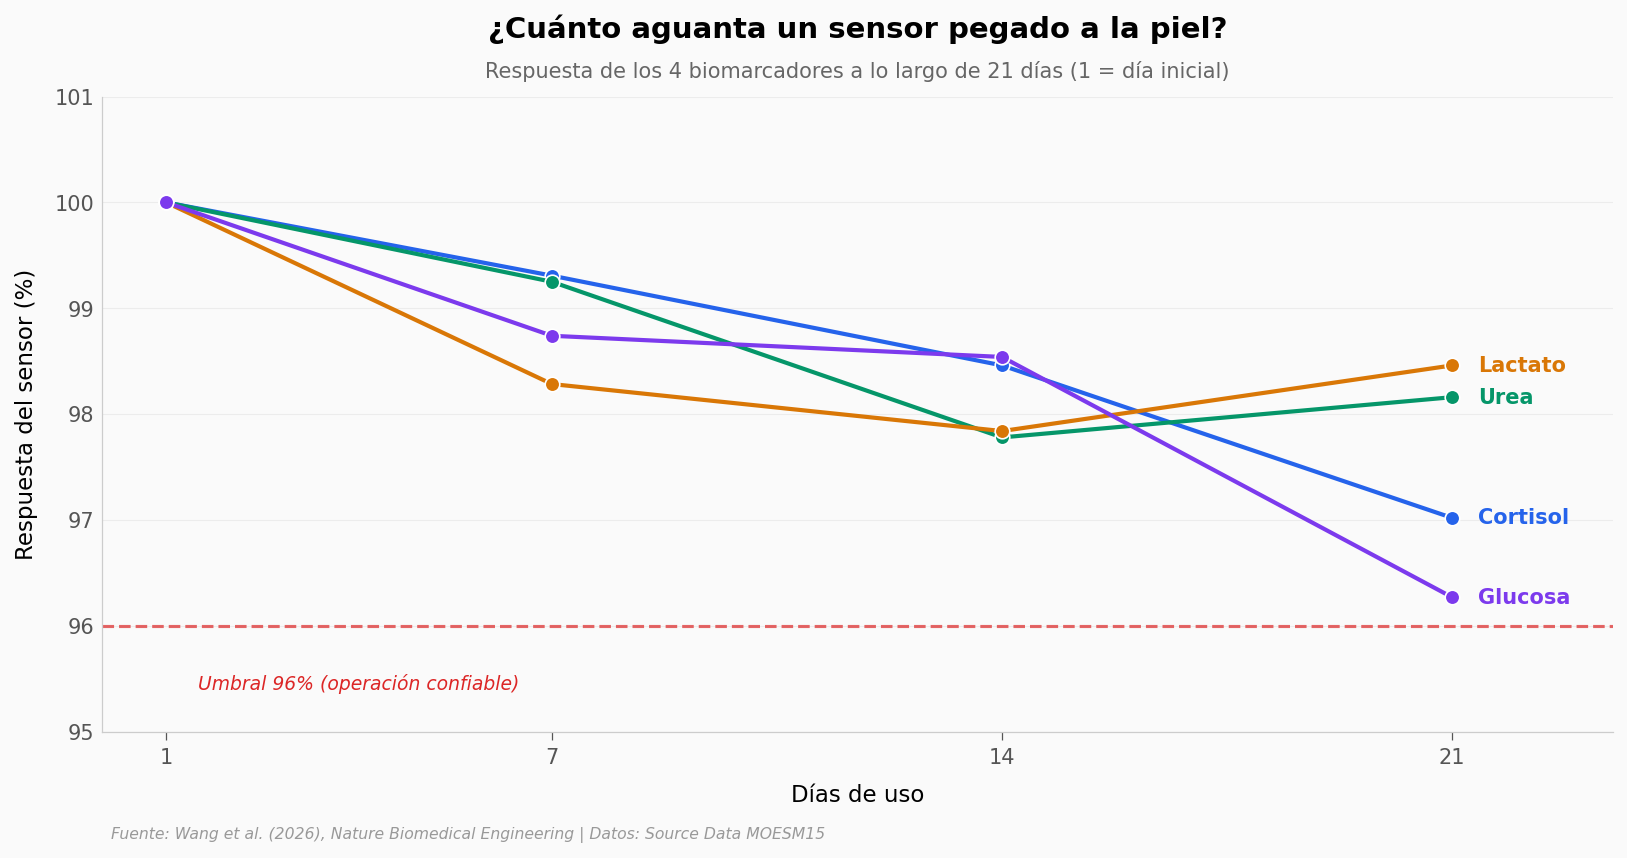


Respuesta al día 21:
  Cortisol  : 97.02%
  Urea      : 98.16%
  Lactato   : 98.46%
  Glucosa   : 96.27%
  Media     : 97.48%
  Pérdida máxima en 21 días: 3.73 puntos


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

dias = estabilidad['dia'].values
sensores = ['sensor_1_pct', 'sensor_2_pct', 'sensor_3_pct', 'sensor_4_pct']
nombres = ['Cortisol', 'Urea', 'Lactato', 'Glucosa']
colores = [COLOR_DATOS, COLOR_SECUNDARIO, COLOR_REFERENCIA, COLOR_VIOLETA]

for sensor, nombre, color in zip(sensores, nombres, colores):
    vals = estabilidad[sensor].values
    ax.plot(dias, vals, color=color, linewidth=2, marker='o', markersize=7,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5)
    # Etiqueta inline al final de cada curva
    ax.text(dias[-1] + 0.4, vals[-1], nombre, fontsize=10,
            color=color, fontweight='bold', va='center')

# Umbral 96% (paper: 'reliable operation' >96%)
ax.axhline(y=RESPUESTA_UMBRAL_PCT, color=COLOR_ALERTA, linewidth=1.5,
           linestyle='--', alpha=0.7)
ax.text(1.5, RESPUESTA_UMBRAL_PCT - 0.6, 'Umbral 96% (operación confiable)',
        fontsize=9, color=COLOR_ALERTA, style='italic')

ax.set_xlabel('Días de uso', fontsize=11)
ax.set_ylabel('Respuesta del sensor (%)', fontsize=11)
ax.set_title('¿Cuánto aguanta un sensor pegado a la piel?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Respuesta de los 4 biomarcadores a lo largo de 21 días (1 = día inicial)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 23.5)
ax.set_ylim(95, 101)
ax.set_xticks([1, 7, 14, 21])

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/estabilidad_21dias.png', dpi=200, bbox_inches='tight')
plt.show()

# Datos numéricos
print('\nRespuesta al día 21:')
for sensor, nombre in zip(sensores, nombres):
    val = estabilidad.loc[estabilidad['dia']==21, sensor].values[0]
    print(f'  {nombre:10s}: {val:.2f}%')
media_d21 = estabilidad.iloc[-1][sensores].mean()
print(f'  {"Media":10s}: {media_d21:.2f}%')
print(f'  Pérdida máxima en 21 días: {100 - estabilidad.iloc[-1][sensores].min():.2f} puntos')

Los 4 biomarcadores se mantienen entre **96.27%** y **98.46%** al día 21. La pérdida máxima en tres semanas es de **3.73 puntos porcentuales** — y eso, en un sensor pegado a la piel, expuesto a sudor real y temperatura corporal, es lo que el paper llama *operación confiable*.

Lo que llama la atención: las curvas no caen en picada. Bajan, sí, pero suavemente y sin cruzar el umbral del 96% que el paper marca como límite operativo. Glucosa es la que más baja (96.27%), seguida de cortisol (97.02%). Urea (98.16%) y lactato (98.46%) aguantan mejor.

¿Qué pasa cuando un electrodo se acerca a ese umbral? Aquí es donde entra el truco que los autores llaman regeneración *in situ* — limpieza sin desmontar nada.

## El sensor se autolimpia

Cuando las moléculas objetivo se acumulan en la superficie del electrodo, el sensor pierde sensibilidad. La solución clásica: cambiarlo. La solución de este equipo: aplicar un voltaje que despega esas moléculas, deja la superficie limpia y el sensor vuelve a su línea base.

Probaron la regeneración en **3 batches independientes** del sensor, en dos etapas: la primera regeneración (Etapa 1) y una segunda regeneración del mismo electrodo (Etapa 2).

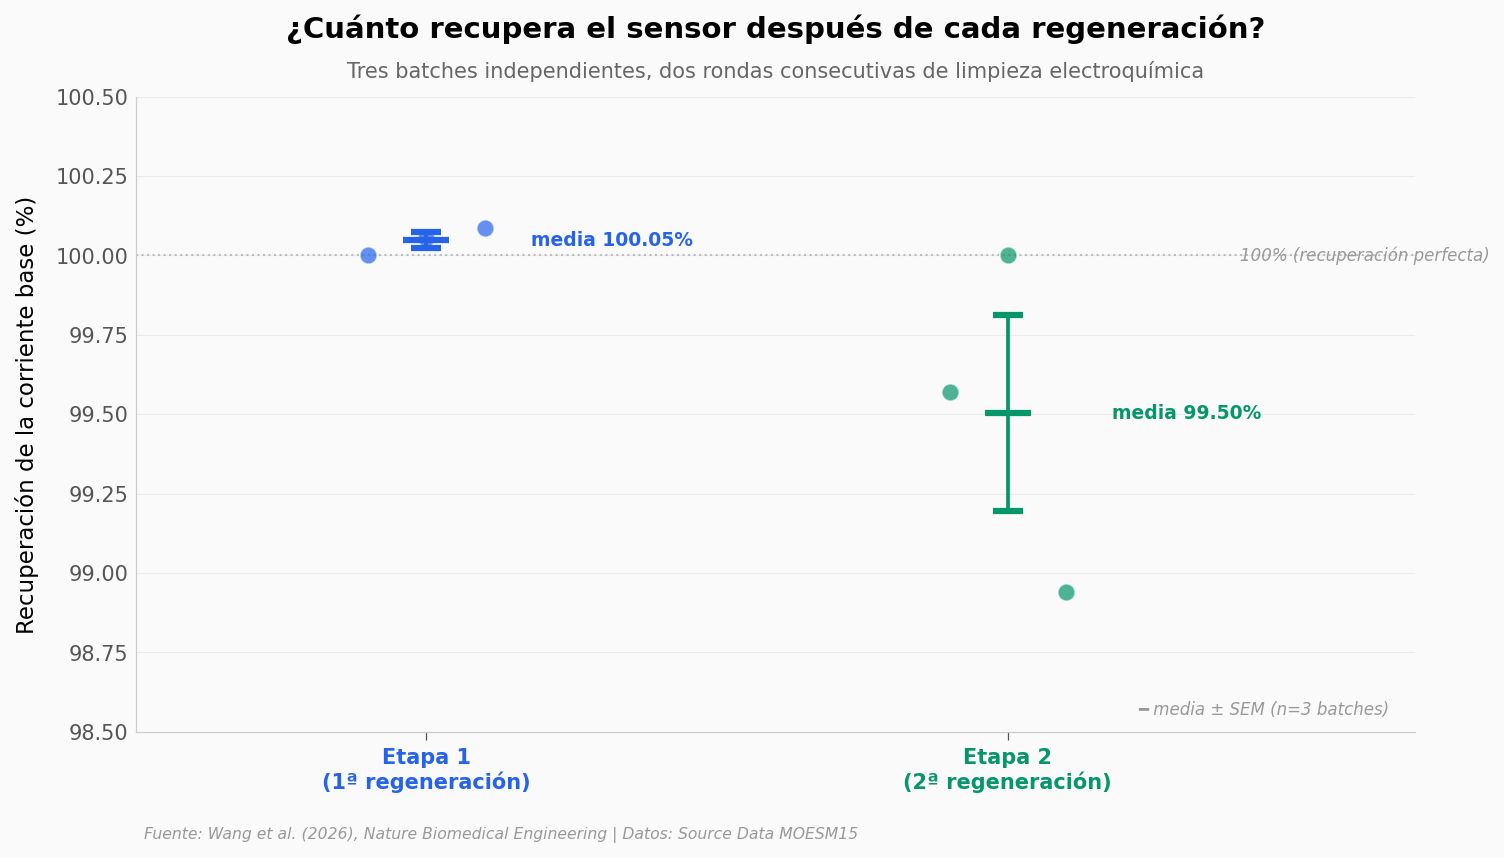


Etapa 1 — rango: 100.00% a 100.09% (media 100.05%)
Etapa 2 — rango: 98.94% a 100.00% (media 99.50%)
Diferencia entre etapas: 0.54 puntos


In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Jitter scatter — Etapa 1 vs Etapa 2 por batch
np.random.seed(42)
etapa1_vals = recup1['recuperacion_pct'].values
etapa2_vals = recup2['recuperacion_pct'].values

posiciones = [0, 1]
labels_grupos = ['Etapa 1\n(1ª regeneración)', 'Etapa 2\n(2ª regeneración)']
colores_grupos = [COLOR_DATOS, COLOR_SECUNDARIO]

for i, (vals, color) in enumerate(zip([etapa1_vals, etapa2_vals], colores_grupos)):
    n = len(vals)
    x_strip = np.linspace(posiciones[i] - 0.10, posiciones[i] + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=70, alpha=0.7,
               edgecolors='white', linewidths=0.8, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(posiciones[i], media, yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=3, capsize=7, capthick=1.5, zorder=6)
    # Anotar la media
    ax.text(posiciones[i] + 0.18, media, f'media {media:.2f}%',
            fontsize=9, color=color, va='center', fontweight='bold')

# Línea de referencia 100%
ax.axhline(y=100, color='#999999', linewidth=1, linestyle=':', alpha=0.6)
ax.text(1.4, 100, '100% (recuperación perfecta)', fontsize=8,
        color='#999999', style='italic', va='center')

ax.set_xticks(posiciones)
ax.set_xticklabels(labels_grupos, fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores_grupos):
    tick.set_color(color)
ax.set_ylabel('Recuperación de la corriente base (%)', fontsize=11)
ax.set_title('¿Cuánto recupera el sensor después de cada regeneración?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tres batches independientes, dos rondas consecutivas de limpieza electroquímica',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.5, 1.7)
ax.set_ylim(98.5, 100.5)

# Nota error bars
ax.text(0.98, 0.02, '━ media ± SEM (n=3 batches)', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/recuperacion_batches.png', dpi=200, bbox_inches='tight')
plt.show()

# Datos numéricos
print(f'\nEtapa 1 — rango: {etapa1_vals.min():.2f}% a {etapa1_vals.max():.2f}% (media {etapa1_vals.mean():.2f}%)')
print(f'Etapa 2 — rango: {etapa2_vals.min():.2f}% a {etapa2_vals.max():.2f}% (media {etapa2_vals.mean():.2f}%)')
print(f'Diferencia entre etapas: {etapa1_vals.mean() - etapa2_vals.mean():.2f} puntos')

## Cuatro maneras de aplicar el voltaje

El "pulso de limpieza" no es uno solo. El equipo probó cuatro técnicas electroquímicas distintas — cada una con su perfil de tiempo y eficiencia: voltametría cíclica (CV), voltametría diferencial de pulso (DPV), cronoamperometría (ECA) y voltametría de barrido lineal (LSV).

La pregunta práctica: ¿cuál limpia más rápido?

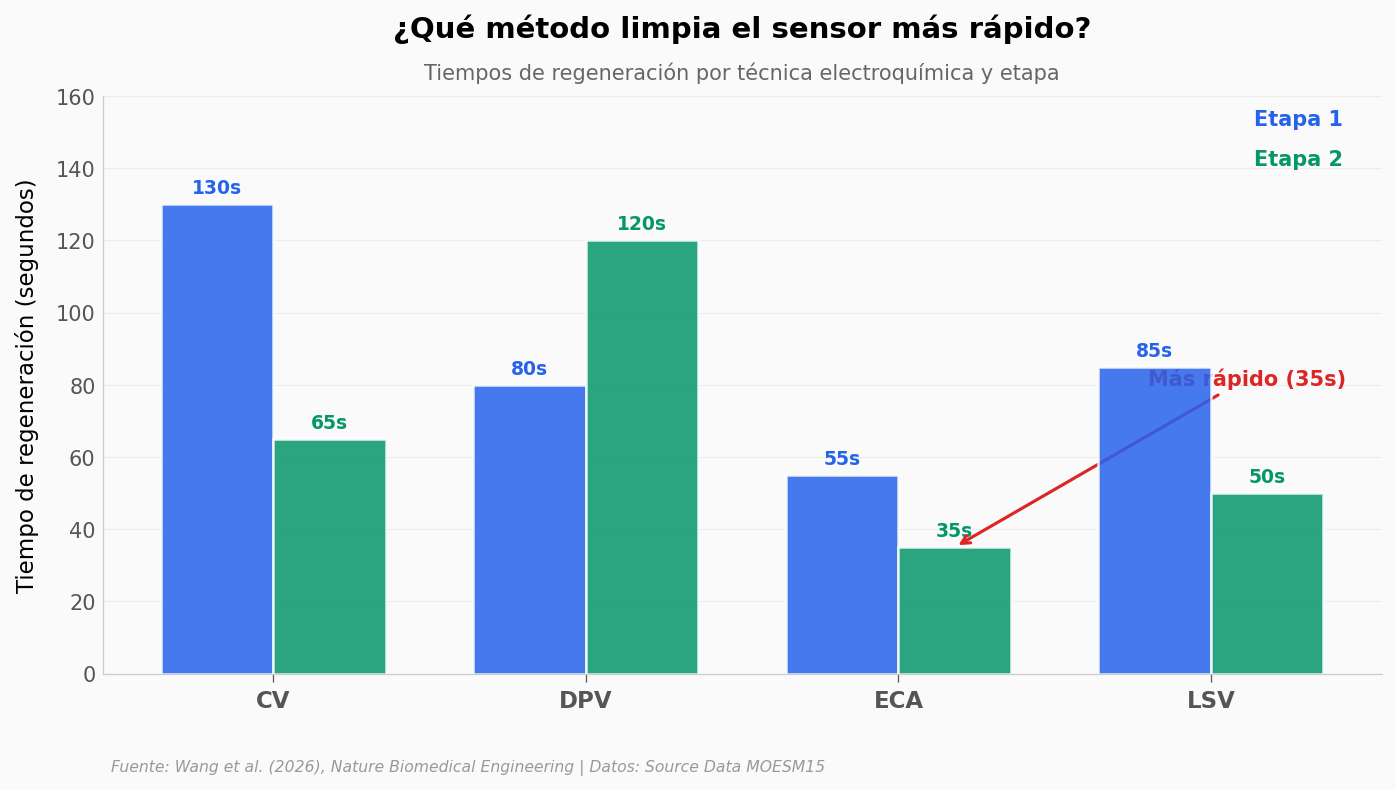


Método más lento (etapa 1): CV — 130s
Método más rápido (etapa 2): ECA — 35s
Rango etapa 1: 55-130s
Rango etapa 2: 35-120s


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

metodos_nombres = metodos['metodo'].values
tiempos_e1 = metodos['tiempo_regeneracion_s_etapa1'].values
tiempos_e2 = metodos['tiempo_regeneracion_s_etapa2'].values

x_pos = np.arange(len(metodos_nombres))
ancho = 0.36

bars1 = ax.bar(x_pos - ancho/2, tiempos_e1, ancho, color=COLOR_DATOS,
               alpha=0.85, edgecolor='white', linewidth=1.2, zorder=5)
bars2 = ax.bar(x_pos + ancho/2, tiempos_e2, ancho, color=COLOR_SECUNDARIO,
               alpha=0.85, edgecolor='white', linewidth=1.2, zorder=5)

# Etiquetas inline encima de las barras
for bar, val in zip(bars1, tiempos_e1):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3, f'{val:.0f}s',
            ha='center', fontsize=9, color=COLOR_DATOS, fontweight='bold')
for bar, val in zip(bars2, tiempos_e2):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3, f'{val:.0f}s',
            ha='center', fontsize=9, color=COLOR_SECUNDARIO, fontweight='bold')

# Etiquetas inline para series (esquina superior derecha)
ax.text(0.97, 0.95, 'Etapa 1', transform=ax.transAxes, fontsize=10,
        color=COLOR_DATOS, fontweight='bold', ha='right')
ax.text(0.97, 0.88, 'Etapa 2', transform=ax.transAxes, fontsize=10,
        color=COLOR_SECUNDARIO, fontweight='bold', ha='right')

# Resaltar el más rápido
idx_min = np.argmin(tiempos_e2)
ax.annotate('Más rápido (35s)',
            xy=(x_pos[idx_min] + ancho/2, tiempos_e2[idx_min]),
            xytext=(x_pos[idx_min] + 0.8, 80),
            fontsize=10, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_xticks(x_pos)
ax.set_xticklabels(metodos_nombres, fontsize=11, fontweight='bold')
ax.set_ylabel('Tiempo de regeneración (segundos)', fontsize=11)
ax.set_title('¿Qué método limpia el sensor más rápido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tiempos de regeneración por técnica electroquímica y etapa',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 160)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/metodos_regeneracion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nMétodo más lento (etapa 1): CV — {tiempos_e1[metodos_nombres.tolist().index("CV")]:.0f}s')
print(f'Método más rápido (etapa 2): ECA — {tiempos_e2[metodos_nombres.tolist().index("ECA")]:.0f}s')
print(f'Rango etapa 1: {tiempos_e1.min():.0f}-{tiempos_e1.max():.0f}s')
print(f'Rango etapa 2: {tiempos_e2.min():.0f}-{tiempos_e2.max():.0f}s')

## ¿Y en humanos?

Hasta aquí, todo en laboratorio. La pregunta que cierra el paper: **¿sirve para algo en una persona real?**

El equipo lo probó en **3 participantes**. Midieron cortisol en reposo y después de una situación de estrés (test cognitivo o ejercicio). La comparación es pareada — el mismo individuo antes y después.

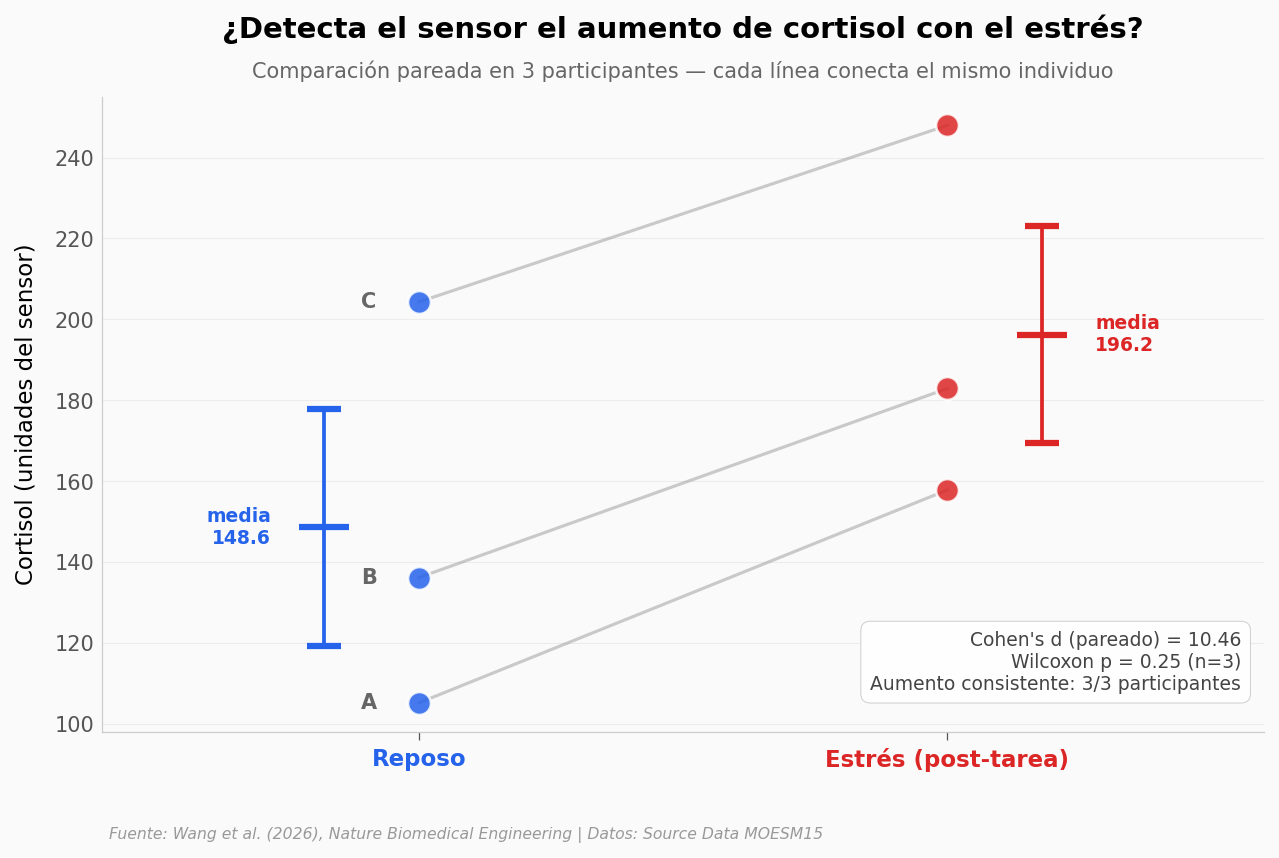


Delta pareado por participante:
  Participant A: 105.2 → 157.8 (+50.0%)
  Participant B: 136.2 → 182.9 (+34.3%)
  Participant C: 204.3 → 248.0 (+21.4%)

Delta absoluto medio: +47.7 unidades
Delta porcentual medio: +35.2%
Cohen's d pareado: 10.46
Wilcoxon p: 0.250 (limitado por n=3)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

participantes = humanos['participante'].values
rest = humanos['cortisol_rest'].values
stress = humanos['cortisol_stress'].values

# Líneas pareadas por participante
for i, (p, r, s) in enumerate(zip(participantes, rest, stress)):
    ax.plot([0, 1], [r, s], color='#999999', linewidth=1.5, alpha=0.5, zorder=3)
    # Etiqueta del participante a la izquierda
    ax.text(-0.08, r, p.replace('Participant ', ''), fontsize=10,
            color='#666666', va='center', ha='right', fontweight='bold')

# Puntos
ax.scatter([0]*len(rest), rest, color=COLOR_DATOS, s=120, alpha=0.85,
           edgecolors='white', linewidths=1.2, zorder=5, label='Reposo')
ax.scatter([1]*len(stress), stress, color=COLOR_ALERTA, s=120, alpha=0.85,
           edgecolors='white', linewidths=1.2, zorder=5, label='Estrés')

# Medias con error bar
mean_r, sem_r = rest.mean(), rest.std(ddof=1) / np.sqrt(len(rest))
mean_s, sem_s = stress.mean(), stress.std(ddof=1) / np.sqrt(len(stress))
ax.errorbar(-0.18, mean_r, yerr=sem_r, fmt='_', color=COLOR_DATOS,
            markersize=24, markeredgewidth=3, capsize=8, capthick=1.5, zorder=6)
ax.errorbar(1.18, mean_s, yerr=sem_s, fmt='_', color=COLOR_ALERTA,
            markersize=24, markeredgewidth=3, capsize=8, capthick=1.5, zorder=6)
ax.text(-0.28, mean_r, f'media\n{mean_r:.1f}', fontsize=9, color=COLOR_DATOS,
        va='center', ha='right', fontweight='bold')
ax.text(1.28, mean_s, f'media\n{mean_s:.1f}', fontsize=9, color=COLOR_ALERTA,
        va='center', ha='left', fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Reposo', 'Estrés (post-tarea)'], fontsize=11, fontweight='bold')
ax.get_xticklabels()[0].set_color(COLOR_DATOS)
ax.get_xticklabels()[1].set_color(COLOR_ALERTA)
ax.set_ylabel('Cortisol (unidades del sensor)', fontsize=11)
ax.set_title('¿Detecta el sensor el aumento de cortisol con el estrés?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Comparación pareada en 3 participantes — cada línea conecta el mismo individuo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.6, 1.6)

# Cohen's d pareado + Wilcoxon
diff = stress - rest
d_pareado = diff.mean() / diff.std(ddof=1)
try:
    w_stat, w_p = stats.wilcoxon(rest, stress, alternative='two-sided')
except Exception:
    w_stat, w_p = float('nan'), float('nan')

ax.text(0.98, 0.06,
        f"Cohen's d (pareado) = {d_pareado:.2f}\n"
        f"Wilcoxon p = {w_p:.2f} (n=3)\n"
        f"Aumento consistente: 3/3 participantes",
        transform=ax.transAxes, fontsize=9, color='#444444',
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.9))

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/validacion_humana.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
print(f'\nDelta pareado por participante:')
for p, r, s in zip(participantes, rest, stress):
    delta_pct = (s - r) / r * 100
    print(f'  {p}: {r:.1f} → {s:.1f} (+{delta_pct:.1f}%)')
print(f'\nDelta absoluto medio: +{diff.mean():.1f} unidades')
print(f'Delta porcentual medio: +{((stress-rest)/rest*100).mean():.1f}%')
print(f"Cohen's d pareado: {d_pareado:.2f}")
print(f'Wilcoxon p: {w_p:.3f} (limitado por n=3)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Operación confiable 21 días | ✅ | Los 4 sensores se mantienen entre 96.27% y 98.46% al día 21. Pérdida máxima: 3.73 puntos. |
| Regeneración in situ funciona | ✅ | Etapa 1: 100.00–100.09% (n=3 batches). Etapa 2: 98.94–100.00% (n=3 batches). Leve degradación tras 2ª regeneración. |
| Detección multimodal (4 biomarcadores) | ✅ | Los 4 canales (cortisol, urea, lactato, glucosa) responden simultáneamente en la curva de 21 días. |
| Selectividad por MIP+DFT | ⚠️ | Los datos de selectividad están en Fig. 2 del paper, no en el Source Data del notebook. Lo tomamos como reportado. |
| Detecta el estrés en humanos | ⚠️ | Aumento consistente en 3/3 participantes (+35.2% medio, Cohen's d pareado = 10.46). El paper lo enmarca como evidencia preliminar — el Wilcoxon con n=3 no alcanza significancia (p=0.25). |
| Aplicaciones futuras en salud y deporte | ⚠️ | El abstract dice *suggesting* — los datos del paper son una prueba de concepto, no validación clínica. |

> **Limitaciones:**
> - Validación humana con **n=3** — el patrón es consistente pero los claims son cualitativos, no inferenciales.
> - El XLSX del Source Data no etiqueta el orden de biomarcadores en la curva de 21 días; los nombramos sensor_1..4 siguiendo el abstract (cortisol, urea, lactato, glucosa).
> - La recuperación de los batches se midió en **n=3 réplicas** — útil para mostrar consistencia, no para inferencia poblacional.
> - **No hay validación contra método gold-standard** (ELISA/HPLC) en los CSVs disponibles del Source Data.

## Ahora tú

Tres preguntas que los datos permiten responder:

**1. ¿Cuál de los 4 sensores se degrada más rápido?**
> Pista: ordena las columnas `sensor_*_pct` por su valor en `dia==21`.

**2. ¿La regeneración pierde eficacia con cada ciclo, o es estable?**
> Pista: compara la media de `recup1` con la de `recup2` y mira la dispersión (`std`).

**3. ¿Hay un participante donde el cortisol NO sube con el estrés?**
> Pista: calcula `stress - rest` por participante. ¿Algún signo negativo o cero?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Cuál sensor se degrada más?
print('Respuesta al día 21 (ordenado de mayor a menor):')
dia21 = estabilidad.iloc[-1][['sensor_1_pct','sensor_2_pct','sensor_3_pct','sensor_4_pct']]
nombres_dict = {'sensor_1_pct':'Cortisol','sensor_2_pct':'Urea','sensor_3_pct':'Lactato','sensor_4_pct':'Glucosa'}
for s, v in dia21.sort_values(ascending=False).items():
    print(f'  {nombres_dict[s]:10s}: {v:.2f}%')

print('\nPregunta 2: ¿La regeneración pierde eficacia?')
print(f'  Etapa 1: media={recup1["recuperacion_pct"].mean():.2f}%, std={recup1["recuperacion_pct"].std(ddof=1):.3f}')
print(f'  Etapa 2: media={recup2["recuperacion_pct"].mean():.2f}%, std={recup2["recuperacion_pct"].std(ddof=1):.3f}')
print(f'  Diferencia de medias: {recup1["recuperacion_pct"].mean() - recup2["recuperacion_pct"].mean():.2f} puntos')

print('\nPregunta 3: ¿Algún participante NO subió cortisol con estrés?')
for _, row in humanos.iterrows():
    delta = row['cortisol_stress'] - row['cortisol_rest']
    signo = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
    print(f'  {row["participante"]}: {row["cortisol_rest"]:.1f} → {row["cortisol_stress"]:.1f} ({signo} {abs(delta):.1f})')

Respuesta al día 21 (ordenado de mayor a menor):
  Lactato   : 98.46%
  Urea      : 98.16%
  Cortisol  : 97.02%
  Glucosa   : 96.27%

Pregunta 2: ¿La regeneración pierde eficacia?
  Etapa 1: media=100.05%, std=0.044
  Etapa 2: media=99.50%, std=0.533
  Diferencia de medias: 0.54 puntos

Pregunta 3: ¿Algún participante NO subió cortisol con estrés?
  Participant A: 105.2 → 157.8 (↑ 52.6)
  Participant B: 136.2 → 182.9 (↑ 46.7)
  Participant C: 204.3 → 248.0 (↑ 43.7)


---

## Fuentes

**Paper**: [Wireless and in situ regenerable multimodal wearable bioelectronic sweat sensor for continuous biomarker monitoring in everyday settings](https://doi.org/10.1038/s41551-026-01670-2)  
*Nature Biomedical Engineering, 2026-05-13*

**Source Data**: [Source Data (MOESM15) — Figures 2-8 raw data](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01670-2/MediaObjects/41551_2026_1670_MOESM15_ESM.xlsx)  
*Datos crudos de figuras 2–8 (XLSX)*

*18 afirmaciones del notebook verificadas contra estas fuentes*

---

**Notebook**: Ciencia a Mordiscos · Lab
**Repo**: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
**Licencia datos**: ver paper (Springer Nature)
**Licencia código**: MIT